# Assignment 3

In [1]:
!pip install tokenizers -q

## Imports and Reproducibility

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import requests
import math
import random
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.decoders import ByteLevel as ByteLevelDecoder

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Data Loading

In [3]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = requests.get(url).text

print("loaded text, length:", len(text))
print(text[:300])

loaded text, length: 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


## BPE Tokenizer Training

In [4]:
with open("shakespeare.txt", "w", encoding="utf-8") as f:
    f.write(text)

tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = ByteLevel()
trainer = BpeTrainer(vocab_size=500, special_tokens=["[UNK]"])
tokenizer.train(["shakespeare.txt"], trainer)
tokenizer.decoder = ByteLevelDecoder()

vocab_size = tokenizer.get_vocab_size()
print("vocab size:", vocab_size)




vocab size: 500


## Sequence Construction and Train/Val Split

In [5]:
token_ids = tokenizer.encode(text).ids
print(f"Total tokens after encoding: {len(token_ids)}")
print(f"Sample: {token_ids[:10]}")

SEQ_LEN = 50

all_inputs, all_targets = [], []
for i in range(len(token_ids) - SEQ_LEN):
    all_inputs.append(token_ids[i : i + SEQ_LEN])
    all_targets.append(token_ids[i + 1 : i + SEQ_LEN + 1])

split_idx = int(0.8 * len(all_inputs))
train_inputs, train_targets = all_inputs[:split_idx], all_targets[:split_idx]
val_inputs,   val_targets   = all_inputs[split_idx:], all_targets[split_idx:]

print("total tokens:", len(token_ids))
print("first few tokens:", token_ids[:10])
print("train:", len(train_inputs), "val:", len(val_inputs))
print("sample input:", train_inputs[0][:6])
print("sample target:", train_targets[0][:6])

Total tokens after encoding: 528901
Sample: [491, 148, 86, 46, 63, 94, 9, 64, 13, 42]
total tokens: 528901
first few tokens: [491, 148, 86, 46, 63, 94, 9, 64, 13, 42]
train: 423080 val: 105771
sample input: [491, 148, 86, 46, 63, 94]
sample target: [148, 86, 46, 63, 94, 9]


## Dataset and DataLoader

In [6]:
class ShakespeareDataset(Dataset):
    def __init__(self, inputs, targets):
        self.inputs  = torch.tensor(inputs,  dtype=torch.long)
        self.targets = torch.tensor(targets, dtype=torch.long)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]

train_dataset = ShakespeareDataset(train_inputs, train_targets)
val_dataset   = ShakespeareDataset(val_inputs,   val_targets)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, drop_last=False)

## Model Architecture

In [7]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class RMSNorm(nn.Module):
    def __init__(self, d_model, eps=1e-8):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(d_model))
        self.eps = eps

    def forward(self, x):
        rms = torch.sqrt(x.pow(2).mean(dim=-1, keepdim=True) + self.eps)
        return self.weight * x / rms


class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads  = n_heads
        self.head_dim = d_model // n_heads
        self.qkv_proj = nn.Linear(d_model, 3 * d_model, bias=False)
        self.out_proj  = nn.Linear(d_model, d_model,     bias=False)
        self.last_attn_weights = None

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv_proj(x)
        q, k, v = qkv.split(C, dim=-1)

        def reshape(t):
            return t.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        q, k, v = reshape(q), reshape(k), reshape(v)

        scale = self.head_dim ** -0.5
        scores = (q @ k.transpose(-2, -1)) * scale

        causal_mask = torch.tril(torch.ones(T, T, device=x.device))
        scores = scores.masked_fill(causal_mask.unsqueeze(0).unsqueeze(0) == 0, float("-inf"))
        attn = F.softmax(scores, dim=-1)

        self.last_attn_weights = attn.detach()

        out = (attn @ v).transpose(1, 2).contiguous().view(B, T, C)
        return self.out_proj(out)


class FeedForward(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.fc1 = nn.Linear(d_model, 4 * d_model)
        self.fc2 = nn.Linear(4 * d_model, d_model)

    def forward(self, x):
        return self.fc2(F.gelu(self.fc1(x)))


class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.norm1 = RMSNorm(d_model)
        self.attn  = CausalSelfAttention(d_model, n_heads)
        self.norm2 = RMSNorm(d_model)
        self.ff    = FeedForward(d_model)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ff(self.norm2(x))
        return x


class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, seq_len):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_enc   = SinusoidalPositionalEncoding(d_model, max_len=seq_len + 10)
        self.blocks    = nn.ModuleList([TransformerBlock(d_model, n_heads) for _ in range(n_layers)])
        self.norm      = RMSNorm(d_model)
        self.lm_head   = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, x):
        x = self.token_emb(x)
        x = self.pos_enc(x)
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        return self.lm_head(x)

    def get_attention_weights(self):
        return [block.attn.last_attn_weights for block in self.blocks]

## Model Initialization

In [8]:
D_MODEL  = 128
N_HEADS  = 4
N_LAYERS = 2
EPOCHS   = 25
LR       = 3e-4

model = TinyTransformer(
    vocab_size=vocab_size,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    seq_len=SEQ_LEN
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("num params:", total_params)

num params: 523136


## Training

epoch 1/25 | train loss: 2.380 | val loss: 3.707 | ppl: 40.7


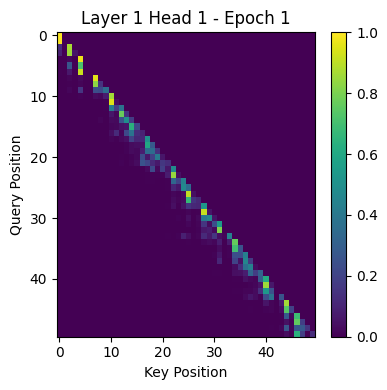

epoch 2/25 | train loss: 2.166 | val loss: 3.977 | ppl: 53.4
epoch 3/25 | train loss: 2.020 | val loss: 4.224 | ppl: 68.3
epoch 4/25 | train loss: 1.914 | val loss: 4.453 | ppl: 85.9
epoch 5/25 | train loss: 1.834 | val loss: 4.677 | ppl: 107.5


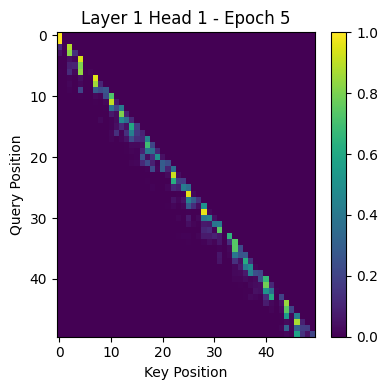

epoch 6/25 | train loss: 1.771 | val loss: 4.855 | ppl: 128.4
epoch 7/25 | train loss: 1.719 | val loss: 5.021 | ppl: 151.5
epoch 8/25 | train loss: 1.677 | val loss: 5.169 | ppl: 175.7
epoch 9/25 | train loss: 1.642 | val loss: 5.290 | ppl: 198.3
epoch 10/25 | train loss: 1.612 | val loss: 5.407 | ppl: 223.0
epoch 11/25 | train loss: 1.586 | val loss: 5.553 | ppl: 257.9
epoch 12/25 | train loss: 1.565 | val loss: 5.630 | ppl: 278.6
epoch 13/25 | train loss: 1.545 | val loss: 5.742 | ppl: 311.6
epoch 14/25 | train loss: 1.529 | val loss: 5.809 | ppl: 333.4
epoch 15/25 | train loss: 1.514 | val loss: 5.878 | ppl: 357.0


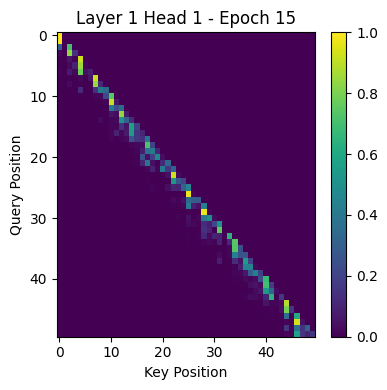

epoch 16/25 | train loss: 1.501 | val loss: 5.960 | ppl: 387.5
epoch 17/25 | train loss: 1.489 | val loss: 6.008 | ppl: 406.5
epoch 18/25 | train loss: 1.477 | val loss: 6.082 | ppl: 438.0
epoch 19/25 | train loss: 1.467 | val loss: 6.128 | ppl: 458.7
epoch 20/25 | train loss: 1.458 | val loss: 6.186 | ppl: 485.9
epoch 21/25 | train loss: 1.450 | val loss: 6.249 | ppl: 517.6
epoch 22/25 | train loss: 1.442 | val loss: 6.305 | ppl: 547.5
epoch 23/25 | train loss: 1.435 | val loss: 6.386 | ppl: 593.3
epoch 24/25 | train loss: 1.428 | val loss: 6.405 | ppl: 604.9
epoch 25/25 | train loss: 1.422 | val loss: 6.443 | ppl: 628.1


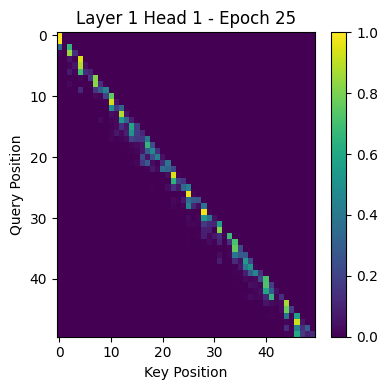


Final Validation Perplexity: 628.14


In [10]:
train_losses = []
val_losses   = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(x_batch)
        loss   = criterion(logits.view(-1, vocab_size), y_batch.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item()

    avg_train = running_loss / len(train_loader)
    train_losses.append(avg_train)

    model.eval()
    running_val = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            logits     = model(x_batch)
            val_loss   = criterion(logits.view(-1, vocab_size), y_batch.view(-1))
            running_val += val_loss.item()

    avg_val = running_val / len(val_loader)
    val_losses.append(avg_val)
    ppl = math.exp(avg_val)

    print(f"epoch {epoch+1}/{EPOCHS} | train loss: {avg_train:.3f} | val loss: {avg_val:.3f} | ppl: {ppl:.1f}")

    if (epoch + 1) in [1, 5, 15, 25]:
        model.eval()
        sample_input = torch.tensor(val_inputs[0], dtype=torch.long).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(sample_input)
        attn = model.get_attention_weights()[0][0][0].cpu().numpy()
        plt.figure(figsize=(4, 4))
        plt.imshow(attn, cmap="viridis", aspect="auto")
        plt.title(f"Layer 1 Head 1 - Epoch {epoch+1}")
        plt.xlabel("Key Position")
        plt.ylabel("Query Position")
        plt.colorbar()
        plt.tight_layout()
        plt.savefig(f"attn_epoch_{epoch+1}.png", dpi=150)
        plt.show()


print("\nFinal Validation Perplexity:", round(math.exp(val_losses[-1]), 2))

## Loss Curves

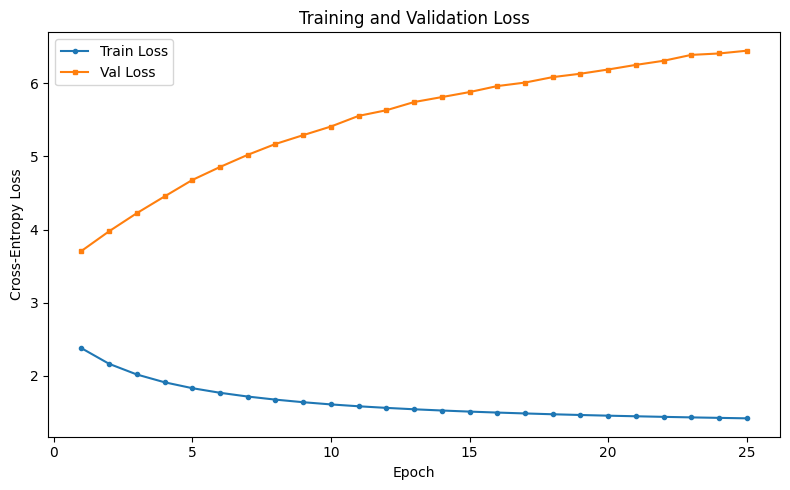

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss", marker="o", markersize=3)
plt.plot(range(1, EPOCHS + 1), val_losses,   label="Val Loss",   marker="s", markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150)
plt.show()

## Attention Heatmaps

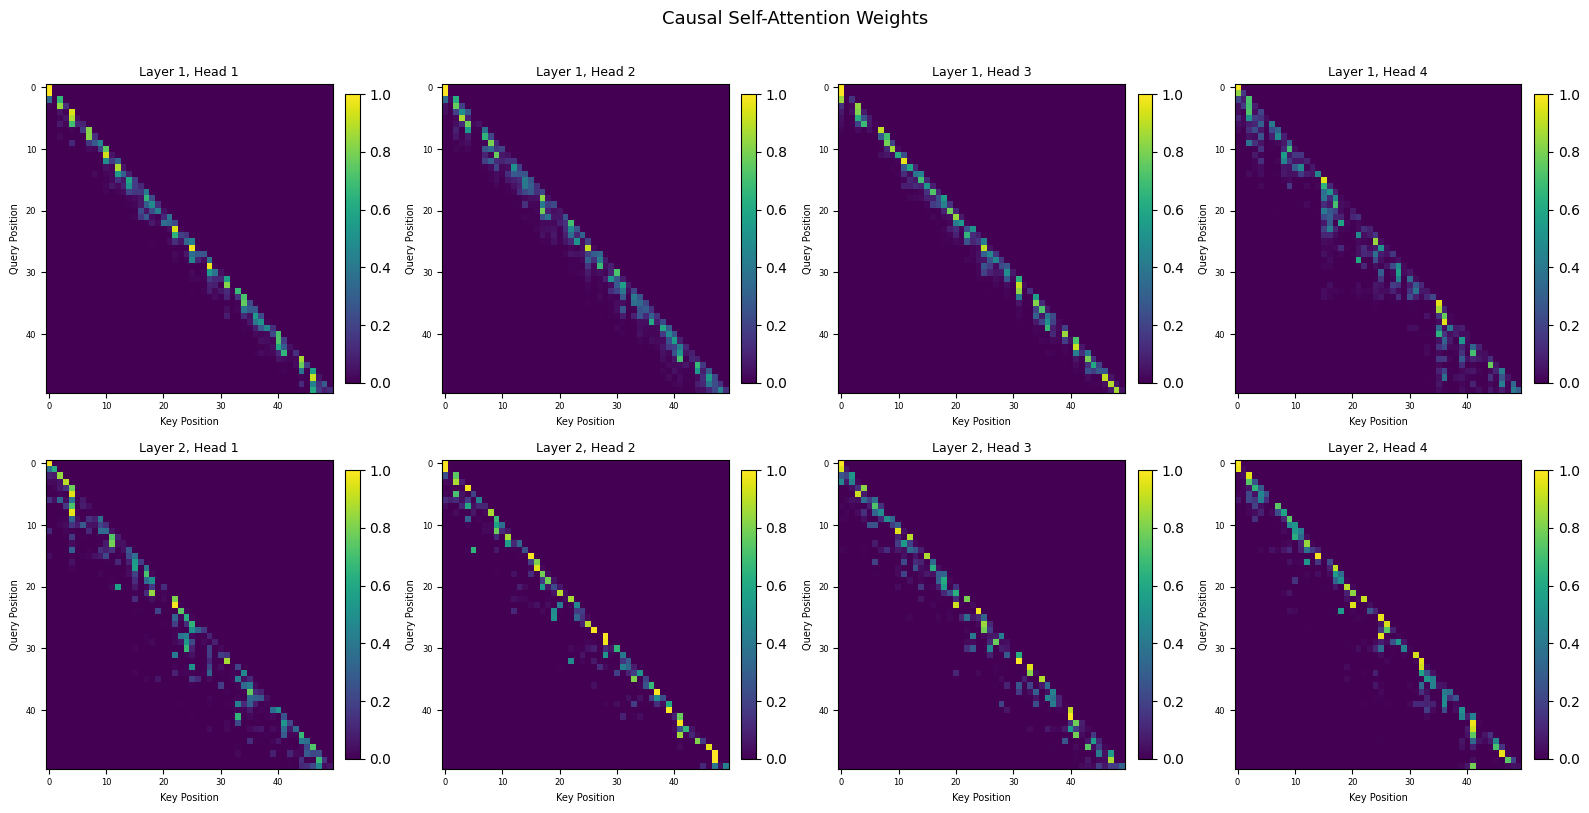

In [12]:
model.eval()

sample_ids   = val_inputs[0]
sample_input = torch.tensor(sample_ids, dtype=torch.long).unsqueeze(0).to(device)
sample_text  = tokenizer.decode(sample_ids[:20]).split()

with torch.no_grad():
    _ = model(sample_input)

attn_all = model.get_attention_weights()

fig, axes = plt.subplots(N_LAYERS, N_HEADS, figsize=(4 * N_HEADS, 4 * N_LAYERS))

for layer_idx in range(N_LAYERS):
    attn_layer = attn_all[layer_idx][0]
    for head_idx in range(N_HEADS):
        ax  = axes[layer_idx][head_idx]
        mat = attn_layer[head_idx].cpu().numpy()
        im  = ax.imshow(mat, cmap="viridis", aspect="auto", vmin=0, vmax=mat.max())
        ax.set_title(f"Layer {layer_idx+1}, Head {head_idx+1}", fontsize=9)
        ax.set_xlabel("Key Position",   fontsize=7)
        ax.set_ylabel("Query Position", fontsize=7)
        ax.tick_params(labelsize=6)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Causal Self-Attention Weights", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("attention_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

## Perplexity Summary

In [13]:
model.eval()
total_val_loss = 0.0
n_batches = 0

with torch.no_grad():
    for x_batch, y_batch in val_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        logits = model(x_batch)
        loss   = criterion(logits.view(-1, vocab_size), y_batch.view(-1))
        total_val_loss += loss.item()
        n_batches += 1

final_val_loss = total_val_loss / n_batches
final_ppl      = math.exp(final_val_loss)

print("Validation Cross-Entropy Loss:", round(final_val_loss, 3))
print("Validation Perplexity:", round(final_ppl, 2))

Validation Cross-Entropy Loss: 6.443
Validation Perplexity: 628.14


## Text Generation

In [14]:
def generate_text(model, tokenizer, prompt, max_new_tokens=150, temperature=0.8, top_k=40):
    model.eval()
    ids = tokenizer.encode(prompt).ids

    with torch.no_grad():
        for _ in range(max_new_tokens):
            context = ids[-SEQ_LEN:]
            x       = torch.tensor(context, dtype=torch.long).unsqueeze(0).to(device)
            logits  = model(x)[0, -1, :] / temperature

            if top_k is not None:
                top_vals, _ = torch.topk(logits, top_k)
                logits[logits < top_vals[-1]] = float("-inf")

            probs      = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1).item()
            ids.append(next_token)

    return tokenizer.decode(ids)

for prompt in ["ROMEO:", "KING HENRY:", "To be or not"]:
    print(f"\nPrompt: '{prompt}'")
    print(generate_text(model, tokenizer, prompt, max_new_tokens=120))
    print()


Prompt: 'ROMEO:'
 ROMEO:
Get you hence, crying finest you have we small vantage,
And his physicians that breaks it off;
For I come.

LEONTES:
Her n swear you more absolute;
I follows it thee heavens upon my head.

BALTHASAR:
Then bring me to her graves.

First Citiz


Prompt: 'KING HENRY:'
 KING HENRY:
Let us be childish'd, how you this be not shame;
The world is not thyself?

WARWICK:
At unawares! what life, if you do me in your require,
The words.

VOLUMNIA:
He had; to saw'd his flowers.
This may be, I'ld yi' changed? a king,
bon--Dear


Prompt: 'To be or not'
 To be or not,
And for his enfaction behind, like a doublet,
Out of thy head and goes oldiction
have as you far off, and go boast of itself
Who had excused of her; where heird a
good married that lives marriagage: but we name,
When nature burns me that I had play
I'll purpose and t



In [15]:
!zip -r images.zip /kaggle/working/*.png

  adding: kaggle/working/attention_heatmaps.png (deflated 20%)
  adding: kaggle/working/attn_epoch_15.png (deflated 14%)
  adding: kaggle/working/attn_epoch_1.png (deflated 14%)
  adding: kaggle/working/attn_epoch_25.png (deflated 14%)
  adding: kaggle/working/attn_epoch_5.png (deflated 14%)
  adding: kaggle/working/loss_curves.png (deflated 12%)
